# CLIP Fine-tuning Stage 1
### Backbone Freeze + Projection Head + CE Head

**차원 정리:**
- 이미지 인코더 출력: 512
- 텍스트 인코더 출력: 768 (DistilBERT) → txt_proj_layer로 512로 맞춤
- ProjectionHead 입력: 512 → 출력: 256
- ClassificationHead 입력: 512 → 출력: 13

**실행 순서:** Cell 1 ~ Cell 6 순서대로 실행 → 학습 완료 후 Cell 7(retrieval 테스트)

In [ ]:
# Cell 1. 환경 설치 및 Drive 마운트
!pip install transformers pillow pandas scikit-learn openpyxl -q 

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 2. 라이브러리 임포트
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel, CLIPVisionModel, CLIPProcessor, AutoTokenizer
from sklearn.model_selection import train_test_split
from transformers import CLIPVisionModelWithProjection

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'디바이스: {device}')

디바이스: cuda


In [ ]:
# Cell 3. 설정값
# ====================================================
# 경로
CSV_PATH   = '/content/drive/MyDrive/metadata_stage1_ready.xlsx'
IMAGE_ROOT = '/content/drive/MyDrive/캡스톤 디자인 - Team Oasis/images_final'
SAVE_PATH  = '/content/drive/MyDrive/checkpoints/stage1/'
# ====================================================

# 차원
IMG_DIM  = 512   # CLIP 이미지 인코더 출력
TXT_DIM  = 768   # DistilBERT 출력
PROJ_DIM = 256   # ProjectionHead 출력

# scene 라벨 (13개)
SCENE_CLASSES = ['바다','산','숲','도시','호수','거리','전통','공원','전망','조형물','카페','온천','전시']
SCENE2IDX     = {s: i for i, s in enumerate(SCENE_CLASSES)}
NUM_CLASSES   = len(SCENE_CLASSES)

# 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 1e-3
LAMBDA_CE  = 0.7

print(f'NUM_CLASSES: {NUM_CLASSES}')
print(f'IMG_DIM: {IMG_DIM}, TXT_DIM: {TXT_DIM}, PROJ_DIM: {PROJ_DIM}')

NUM_CLASSES: 13
IMG_DIM: 512, TXT_DIM: 768, PROJ_DIM: 256


In [ ]:
# Cell 4. 모델 로드 + Head 정의

# ── Backbone 로드 ──────────────────────────────────────
TEXT_MODEL_NAME   = 'sentence-transformers/clip-ViT-B-32-multilingual-v1'
VISION_MODEL_NAME = 'openai/clip-vit-base-patch32'

text_encoder   = DistilBertModel.from_pretrained(TEXT_MODEL_NAME).to(device)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

vision_encoder = CLIPVisionModelWithProjection.from_pretrained(VISION_MODEL_NAME).to(device)
processor      = CLIPProcessor.from_pretrained(VISION_MODEL_NAME)

# Backbone Freeze
for param in text_encoder.parameters():
    param.requires_grad = False
for param in vision_encoder.parameters():
    param.requires_grad = False

print('Backbone freeze 완료')

# ── Head 정의 ──────────────────────────────────────────

# 텍스트 차원 맞추기: 768 → 512
txt_proj_layer = nn.Linear(TXT_DIM, IMG_DIM).to(device)

class ProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, IMG_DIM),
            nn.ReLU(),
            nn.Linear(IMG_DIM, PROJ_DIM)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class ClassificationHead(nn.Module):
    """이미지 512 → 13 (scene 분류)"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        return self.net(x)

proj_head = ProjectionHead().to(device)
cls_head  = ClassificationHead().to(device)

trainable = (sum(p.numel() for p in proj_head.parameters()) +
             sum(p.numel() for p in cls_head.parameters()) +
             sum(p.numel() for p in txt_proj_layer.parameters()))
print(f'학습 파라미터 수 (heads): {trainable:,}')
print('  txt_proj_layer : 768 → 512')
print('  ProjectionHead : 512 → 256')
print('  ClassificationHead : 512 → 13')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/539M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/371 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Backbone freeze 완료
학습 파라미터 수 (heads): 922,381
  txt_proj_layer : 768 → 512
  ProjectionHead : 512 → 256
  ClassificationHead : 512 → 13


In [ ]:
import os
import unicodedata
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# --- [추가] 한글 인코딩 문제 해결을 위한 정규화 함수 ---
def dn(text):
    if pd.isna(text): return ""
    return unicodedata.normalize('NFC', str(text)).strip()

# --- [추가] 실제 폴더 안의 파일들을 미리 스캔 (딱 한 번만 실행) ---
# 엑셀의 이름과 실제 파일명이 인코딩 차이로 다를 때를 대비해 매핑 테이블을 만듭니다.
print("🔎 이미지 폴더 스캔 중...")
actual_file_map = {dn(f): f for f in os.listdir(IMAGE_ROOT) if not f.startswith('.')}
print(f"✅ 총 {len(actual_file_map)}개의 실제 파일 인식 완료.")

class TravelDataset(Dataset):
    def __init__(self, df, image_root, processor, tokenizer, scene2idx):
        self.df         = df.reset_index(drop=True)
        self.image_root = image_root
        self.processor  = processor
        self.tokenizer  = tokenizer
        self.scene2idx  = scene2idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. 엑셀에 적힌 이미지 아이디 정규화
        target_id = dn(row['image_id'])

        # 2. 매핑 테이블에서 실제 파일명 찾기
        real_file_name = actual_file_map.get(target_id)

        if real_file_name is None:
            # 파일이 없을 경우 에러 메시지를 명확히 출력
            raise FileNotFoundError(f"❌ 파일 없음: {target_id} (엑셀 행 번호: {idx})")

        img_path = os.path.join(self.image_root, real_file_name)

        # 이미지 로드 및 처리
        try:
            image = Image.open(img_path).convert('RGB')
            pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        except Exception as e:
            print(f"❌ 이미지 로드 실패: {img_path}")
            raise e

        # 텍스트 처리
        enc = self.tokenizer(
            str(row['caption']),
            padding='max_length', max_length=64,
            truncation=True, return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        # scene 라벨
        scene_label = self.scene2idx.get(str(row['scene']), 0)

        return pixel_values, input_ids, attention_mask, scene_label

# --- 데이터 로드 및 분할 ---
df = pd.read_excel(CSV_PATH)

# [중요] 엑셀의 image_id가 실제 파일과 매칭되는지 전수 검사 (미리 에러 방지)
df['is_file_exist'] = df['image_id'].apply(lambda x: dn(x) in actual_file_map)
missing_files = df[df['is_file_exist'] == False]

if len(missing_files) > 0:
    print(f"⚠️ 경고: 엑셀 명단 중 {len(missing_files)}개의 파일이 폴더에 없습니다!")
    print(f"예시: {missing_files['image_id'].iloc[0]}")
    # 파일이 없는 행은 학습에서 아예 제외
    df = df[df['is_file_exist'] == True].copy()

print('\nscene 분포:')
print(df['scene'].value_counts())

unknown = set(df['scene'].unique()) - set(SCENE_CLASSES)
if unknown:
    print(f'\n⚠️ SCENE_CLASSES에 없는 값: {unknown}')

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f'\n최종 Train: {len(train_df)}장 / Val: {len(val_df)}장')

# 데이터로더 생성
train_dataset = TravelDataset(train_df, IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)
val_dataset   = TravelDataset(val_df,   IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)

# num_workers=2가 가끔 코랩에서 에러를 내면 0으로 바꾸세요.
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train 배치 수: {len(train_loader)} / Val 배치 수: {len(val_loader)}')

🔎 이미지 폴더 스캔 중...
✅ 총 4846개의 실제 파일 인식 완료.
⚠️ 경고: 엑셀 명단 중 57개의 파일이 폴더에 없습니다!
예시: 숨도_5_공공3유형.jpg

scene 분포:
scene
전통     880
공원     819
바다     555
거리     333
숲      282
도시     278
산      242
전망     227
호수     214
조형물    213
카페     139
전시      18
온천       3
Name: count, dtype: int64

최종 Train: 3782장 / Val: 421장
Train 배치 수: 119 / Val 배치 수: 14


In [ ]:
# Cell 6. 학습

logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
ce_loss_fn  = nn.CrossEntropyLoss()

def clip_loss(img_norm, txt_norm):
    """img_norm, txt_norm: (B, 512) L2 normalize 완료"""
    scale    = logit_scale.exp().to(img_norm.device)
    logits_i = scale * img_norm @ txt_norm.T
    logits_t = logits_i.T
    labels   = torch.arange(len(img_norm), device=device)
    return (F.cross_entropy(logits_i, labels) + F.cross_entropy(logits_t, labels)) / 2


optimizer = torch.optim.AdamW(
    list(proj_head.parameters()) +
    list(cls_head.parameters()) +
    list(txt_proj_layer.parameters()) +
    [logit_scale],
    lr=LR, weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

os.makedirs(SAVE_PATH, exist_ok=True)
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):

    # ── Train ──────────────────────────────────────────
    vision_encoder.eval()    # Backbone eval 고정
    text_encoder.eval()
    proj_head.train()
    cls_head.train()
    txt_proj_layer.train()

    train_loss = 0
    for pixel_values, input_ids, attention_mask, scene_labels in train_loader:
        pixel_values   = pixel_values.to(device)
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        scene_labels   = scene_labels.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            img_feat = vision_encoder(pixel_values=pixel_values).image_embeds   # (B, 512)
            txt_out  = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            txt_feat = txt_out.last_hidden_state[:, 0, :]                       # (B, 768)

        txt_feat = txt_proj_layer(txt_feat)          # (B, 768) → (B, 512)

        img_norm   = F.normalize(img_feat, dim=-1)   # (B, 512)
        txt_norm   = F.normalize(txt_feat, dim=-1)   # (B, 512)

        img_proj   = proj_head(img_feat)             # (B, 256) SupCon용
        cls_logits = cls_head(img_feat)              # (B, 13)

        l_clip = clip_loss(img_norm, txt_norm)
        l_ce   = ce_loss_fn(cls_logits, scene_labels)
        loss   = l_clip + LAMBDA_CE * l_ce

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(proj_head.parameters()) +
            list(cls_head.parameters()) +
            list(txt_proj_layer.parameters()),
            max_norm=1.0
        )
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    # ── Validation ─────────────────────────────────────
    proj_head.eval()
    cls_head.eval()
    txt_proj_layer.eval()

    val_loss, val_correct, val_total = 0, 0, 0

    for pixel_values, input_ids, attention_mask, scene_labels in val_loader:
        pixel_values   = pixel_values.to(device)
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        scene_labels   = scene_labels.to(device)
        with torch.no_grad():
          img_feat = vision_encoder(pixel_values=pixel_values).image_embeds   # (B, 512)
          txt_out  = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
          txt_feat = txt_out.last_hidden_state[:, 0, :]

        txt_feat = txt_proj_layer(txt_feat)          # (B, 512)

        img_norm   = F.normalize(img_feat, dim=-1)
        txt_norm   = F.normalize(txt_feat, dim=-1)
        cls_logits = cls_head(img_feat)

        l_clip = clip_loss(img_norm, txt_norm)
        l_ce   = ce_loss_fn(cls_logits, scene_labels)
        loss   = l_clip + LAMBDA_CE * l_ce

        val_loss += loss.item()
        preds = cls_logits.argmax(dim=-1)
        val_correct += (preds == scene_labels).sum().item()
        val_total   += len(scene_labels)

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    val_acc   = val_correct / val_total * 100

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train: {avg_train:.4f} | Val: {avg_val:.4f} | Scene Acc: {val_acc:.1f}%')

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            'epoch'         : epoch + 1,
            'proj_head'     : proj_head.state_dict(),
            'cls_head'      : cls_head.state_dict(),
            'txt_proj_layer': txt_proj_layer.state_dict(),
            'logit_scale'   : logit_scale.data,
            'val_loss'      : best_val_loss,
            'val_acc'       : val_acc
        }, os.path.join(SAVE_PATH, 'best.pt'))
        print(f'  → Best 저장 (val_loss: {best_val_loss:.4f})')

print('\nStage 1 학습 완료!')

Best epoch: 5, val_loss: 2.2665, scene acc: 67.5%


/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2208/160261326.py:66: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

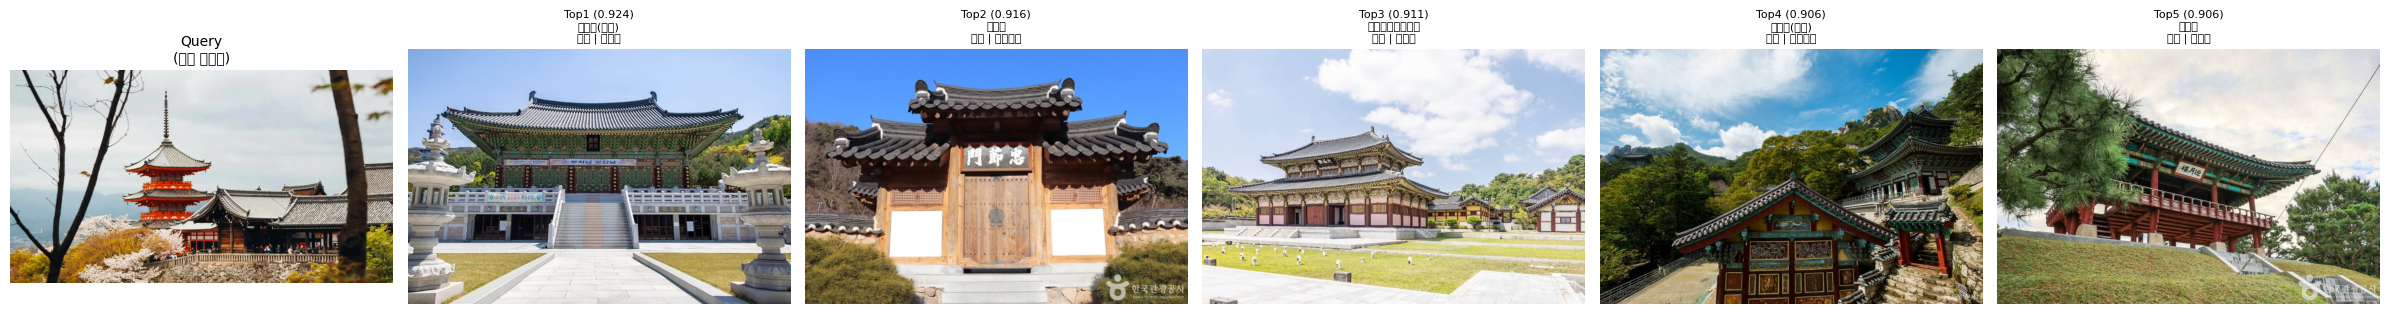


--- 검색 결과 ---
Top 1 | 도림사(대구) | 전통 | 웅장한 | 유사도: 0.9241
Top 2 | 모영재 | 전통 | 고즈넉한 | 유사도: 0.9165
Top 3 | 김해가야테마파크 | 전통 | 세련된 | 유사도: 0.9108
Top 4 | 망월사(경기) | 전통 | 고즈넉한 | 유사도: 0.9061
Top 5 | 영월루 | 전통 | 웅장한 | 유사도: 0.9057


In [ ]:
# Cell 7. Retrieval 테스트 — 학습 완료 후 실행
import matplotlib.pyplot as plt

logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
ce_loss_fn  = nn.CrossEntropyLoss()

# Best 체크포인트 불러오기
ckpt = torch.load(os.path.join(SAVE_PATH, 'best.pt'))
proj_head.load_state_dict(ckpt['proj_head'])
cls_head.load_state_dict(ckpt['cls_head'])
txt_proj_layer.load_state_dict(ckpt['txt_proj_layer'])
logit_scale.data = ckpt['logit_scale']
print(f"Best epoch: {ckpt['epoch']}, val_loss: {ckpt['val_loss']:.4f}, scene acc: {ckpt['val_acc']:.1f}%")

# 국내 이미지 전체 embedding 추출
vision_encoder.eval()
proj_head.eval()

all_embeddings = []
all_metadata   = df[['image_id', 'place_name', 'primary_mood', 'scene']].to_dict('records')
full_dataset   = TravelDataset(df, IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)
full_loader    = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=2)

with torch.no_grad():
    for pixel_values, _, _, _ in full_loader:
        pixel_values = pixel_values.to(device)
        img_feat = vision_encoder(pixel_values=pixel_values).image_embeds   # (B, 512)
        img_proj     = proj_head(img_feat)   # (B, 256)
        all_embeddings.append(img_proj.cpu().numpy())

#불러오는코드
# all_embeddings = np.load('/content/drive/MyDrive/checkpoints/stage1/embeddings.npy')
all_embeddings = np.vstack(all_embeddings)

def retrieve(query_image_path, top_k=5):
    img = Image.open(query_image_path).convert('RGB')
    pv  = processor(images=img, return_tensors='pt')['pixel_values'].to(device)
    with torch.no_grad():
        feat = vision_encoder(pixel_values=pv).image_embeds   # (B, 512)
        proj = proj_head(feat).cpu().numpy()
    sims        = (all_embeddings @ proj.T).squeeze()
    top_indices = np.argsort(sims)[::-1][:top_k]
    return [{
        'image_id'    : all_metadata[i]['image_id'],
        'place_name'  : all_metadata[i]['place_name'],
        'primary_mood': all_metadata[i]['primary_mood'],
        'scene'       : all_metadata[i]['scene'],
        'score'       : float(sims[i])
    } for i in top_indices]


def show_results(query_path, results):
    n = len(results) + 1
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes[0].imshow(Image.open(query_path))
    axes[0].set_title('Query\n(해외 이미지)', fontsize=10)
    axes[0].axis('off')
    for i, r in enumerate(results):
        img_path = os.path.join(IMAGE_ROOT, f"{r['image_id']}")
        axes[i+1].imshow(Image.open(img_path))
        axes[i+1].set_title(
            f"Top{i+1} ({r['score']:.3f})\n{r['place_name']}\n{r['scene']} | {r['primary_mood']}",
            fontsize=8
        )
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.show()


# ← 여기만 바꾸면 됨
QUERY_IMAGE = '/content/drive/MyDrive/교토.jpg'

results = retrieve(QUERY_IMAGE, top_k=5)
show_results(QUERY_IMAGE, results)

print('\n--- 검색 결과 ---')
for i, r in enumerate(results):
    print(f"Top {i+1} | {r['place_name']} | {r['scene']} | {r['primary_mood']} | 유사도: {r['score']:.4f}")

In [ ]:
np.save('/content/drive/MyDrive/checkpoints/stage1/embeddings.npy', all_embeddings)
print(f'전체 embedding shape: {all_embeddings.shape}')

전체 embedding shape: (4203, 256)
